In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.feature_sets import BASE_TABULAR_FEATURES, GCMT_FEATURES
from src.models.input_layer import load_modeling_splits

DATASET_NAME = "earthquake_aftershock_v2_gcmt"

splits = load_modeling_splits(dataset_name=DATASET_NAME)
train_df = splits["train"].copy()
val_df   = splits["val"].copy()
test_df  = splits["test"].copy()

print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Train: 23,031 rows
Val:   1,744 rows
Test:  3,513 rows


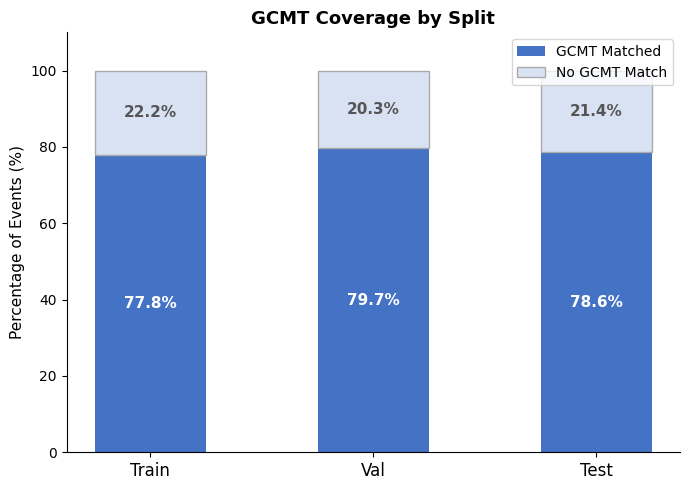

In [5]:
def gcmt_missing_pct(df):
    available_cols = [c for c in GCMT_FEATURES if c in df.columns]
    return df[available_cols].isna().any(axis=1).mean() * 100

train_missing = gcmt_missing_pct(train_df)
val_missing   = gcmt_missing_pct(val_df)
test_missing  = gcmt_missing_pct(test_df)

present_pcts = [100 - train_missing, 100 - val_missing, 100 - test_missing]
missing_pcts = [train_missing, val_missing, test_missing]
splits_labels = ['Train', 'Val', 'Test']
x = np.arange(len(splits_labels))
width = 0.5

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, present_pcts, width, label='GCMT Matched',   color='#4472C4')
ax.bar(x, missing_pcts, width, bottom=present_pcts, label='No GCMT Match', color='#D9E2F3', edgecolor='#AAAAAA')

for i, (p, m) in enumerate(zip(present_pcts, missing_pcts)):
    ax.text(i, p / 2,     f'{p:.1f}%', ha='center', va='center', color='white',   fontweight='bold', fontsize=11)
    ax.text(i, p + m / 2, f'{m:.1f}%', ha='center', va='center', color='#555555', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(splits_labels, fontsize=12)
ax.set_ylabel('Percentage of Events (%)', fontsize=11)
ax.set_title('GCMT Coverage by Split', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('gcmt_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# check how missingness actually looks
print("GCMT_FEATURES columns:", GCMT_FEATURES)
print()
print("Missing % per GCMT column (train):")
for col in GCMT_FEATURES:
    if col in train_df.columns:
        pct = train_df[col].isna().mean() * 100
        print(f"  {col}: {pct:.1f}%")
    else:
        print(f"  {col}: NOT IN DATAFRAME")

GCMT_FEATURES columns: ['has_gcmt', 'gcmt_time_diff_sec', 'gcmt_distance_km', 'gcmt_mag_diff', 'gcmt_latitude', 'gcmt_longitude', 'gcmt_depth_km', 'gcmt_magnitude', 'strike', 'dip', 'rake', 'gcmt_half_duration_sec', 'gcmt_centroid_time_shift_sec', 'gcmt_centroid_time_shift_error_sec', 'gcmt_latitude_error', 'gcmt_longitude_error', 'gcmt_depth_error_km', 'gcmt_moment_exponent', 'gcmt_mrr', 'gcmt_mrr_error', 'gcmt_mtt', 'gcmt_mtt_error', 'gcmt_mpp', 'gcmt_mpp_error', 'gcmt_mrt', 'gcmt_mrt_error', 'gcmt_mrp', 'gcmt_mrp_error', 'gcmt_mtp', 'gcmt_mtp_error', 'gcmt_eig1', 'gcmt_eig1_plunge', 'gcmt_eig1_azimuth', 'gcmt_eig2', 'gcmt_eig2_plunge', 'gcmt_eig2_azimuth', 'gcmt_eig3', 'gcmt_eig3_plunge', 'gcmt_eig3_azimuth', 'gcmt_scalar_moment', 'strike2', 'dip2', 'rake2']

Missing % per GCMT column (train):
  has_gcmt: 0.0%
  gcmt_time_diff_sec: 22.2%
  gcmt_distance_km: 22.2%
  gcmt_mag_diff: 22.2%
  gcmt_latitude: 22.2%
  gcmt_longitude: 22.2%
  gcmt_depth_km: 22.2%
  gcmt_magnitude: 22.2%
  st

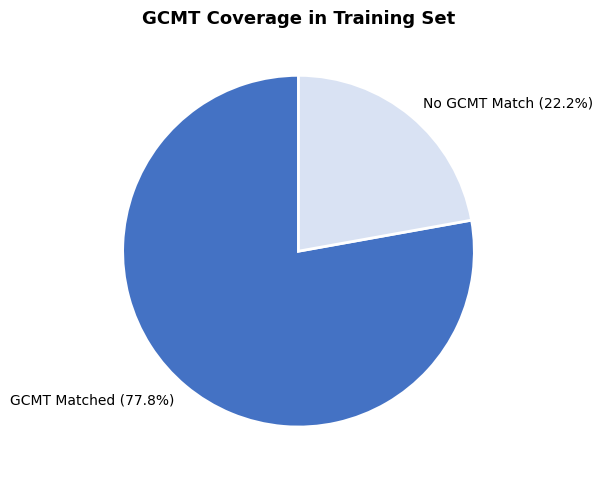

In [4]:
def gcmt_missing_pct(df):
    available_cols = [c for c in GCMT_FEATURES if c in df.columns]
    # a row is "unmatched" if ANY gcmt col is NaN (they're all NaN or all present together)
    return df[available_cols].isna().any(axis=1).mean() * 100

train_missing = gcmt_missing_pct(train_df)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [100 - train_missing, train_missing],
    labels=[f'GCMT Matched ({100 - train_missing:.1f}%)', f'No GCMT Match ({train_missing:.1f}%)'],
    colors=['#4472C4', '#D9E2F3'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('GCMT Coverage in Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gcmt_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

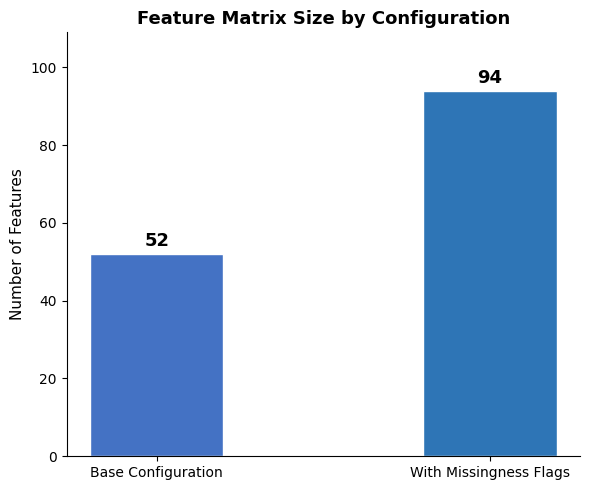

Base features: 52
Missingness flag columns added: 42
Expanded features: 94


In [6]:
# derive feature counts from actual data
gcmt_missing_flag_cols = [c for c in GCMT_FEATURES if train_df[c].isna().mean() > 0.05]

base_count     = len(BASE_TABULAR_FEATURES) + len(GCMT_FEATURES)
expanded_count = base_count + len(gcmt_missing_flag_cols)

fig, ax = plt.subplots(figsize=(6, 5))

configs = ['Base Configuration', 'With Missingness Flags']
counts  = [base_count, expanded_count]
colors  = ['#4472C4', '#2E75B6']

bars = ax.bar(configs, counts, width=0.4, color=colors, edgecolor='white')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylabel('Number of Features', fontsize=11)
ax.set_title('Feature Matrix Size by Configuration', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(counts) + 15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Base features: {base_count}")
print(f"Missingness flag columns added: {len(gcmt_missing_flag_cols)}")
print(f"Expanded features: {expanded_count}")